In [1]:
import cryo
import polars as pl
import binascii
import web3
import json
from eth_abi import decode
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import numpy as np

In [2]:
# The multical cantract address, but we also need ABI
MULTICALL3_ADDRESS = '0xcA11bde05977b3631167028862bE2a173976CA11'
MULTICALL3_ABI=json.loads('[{"inputs":[{"internalType":"bool","name":"requireSuccess","type":"bool"},{"components":[{"internalType":"address","name":"target","type":"address"},{"internalType":"bytes","name":"callData","type":"bytes"}],"internalType":"struct Multicall3.Call[]","name":"calls","type":"tuple[]"}],"name":"tryAggregate","outputs":[{"components":[{"internalType":"bool","name":"success","type":"bool"},{"internalType":"bytes","name":"returnData","type":"bytes"}],"internalType":"struct Multicall3.Result[]","name":"returnData","type":"tuple[]"}],"stateMutability":"payable","type":"function"}]')

In [3]:
# Contract Addresses
UNIV3_USDC_ETH='0x88e6A0c2dDD26FEEb64F039a2c41296FcB3f5640'

In [4]:
# Function Signatures 4 bytes
getBlocknumber_4b = '42cbb15c'
getBloclTimestamp_4b= '0f28c97d'
getReserves_4b = '0902f1ac'
slot0_4b = '3850c7bd'

In [5]:
# Functions
def bytes_to_hexstr(b: any) -> str:
    if isinstance(b,list):
        return [bytes_to_hexstr(a) for a in b]
    return '0x' + b.hex()

def decode_outputdata_uniV3_price(b: bytes) -> list[float]:
    aggregated_data_uniV3 = decode(['(bool,bytes)[]'], b)[0]

    # UNI-V3
    # slot0():
    # sqrtPriceX96 uint160, tick int24, observationIndex uint16, observationCardinality uint16, observationCardinalityNext uint16, feeProtocol uint8, unlocked bool
    # 'uint160', 'int24', 'uint16', 'uint16', 'uint16', 'uint8', 'bool'
    usdc_eth_slot0_raw = aggregated_data_uniV3[0]
    usdc_eth_slot0_sqrt_ratioX96 = decode(['uint160', 'int24', 'uint16', 'uint16', 'uint16', 'uint8', 'bool'], usdc_eth_slot0_raw[1])[0]
    usdc_eth_price = usdc_eth_slot0_sqrt_ratioX96**2 / 2**192 /1e12
    eth_usdc_price_v3 = 1/usdc_eth_price

    # Timestamp
    timestamp_raw = aggregated_data_uniV3[-1]
    timestamp = int(timestamp_raw[1].hex(),16)

    block_raw = aggregated_data_uniV3[-2]
    block_number = int(block_raw[1].hex(),16)
    
    return [eth_usdc_price_v3, timestamp, block_number]
    

In [6]:
# web3 instance, function from web3py
w3 = web3.Web3()
m3 = w3.eth.contract(address = MULTICALL3_ADDRESS, abi=MULTICALL3_ABI)

In [7]:
# Arguments fro the tryAggregate Fuunction
aggregate_calldata = [
    [
        UNIV3_USDC_ETH,
        f'0x{slot0_4b}',
    ],
    [
        MULTICALL3_ADDRESS,
        f'0x{getBloclTimestamp_4b}',
    ],
    [
        MULTICALL3_ADDRESS,
        f'0x{getBlocknumber_4b}',
    ],
]

In [8]:
# aggregate_calldata list of list
# Generate calldate (the input) via m3 Multicall3 encode ABIfor cryo - calldata is in Hex format
calldata = m3.encode_abi("tryAggregate", args=[False, aggregate_calldata])

In [9]:
calldata

'0xbce38bd7000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000400000000000000000000000000000000000000000000000000000000000000003000000000000000000000000000000000000000000000000000000000000006000000000000000000000000000000000000000000000000000000000000000e0000000000000000000000000000000000000000000000000000000000000016000000000000000000000000088e6a0c2ddd26feeb64f039a2c41296fcb3f5640000000000000000000000000000000000000000000000000000000000000004000000000000000000000000000000000000000000000000000000000000000043850c7bd00000000000000000000000000000000000000000000000000000000000000000000000000000000ca11bde05977b3631167028862be2a173976ca11000000000000000000000000000000000000000000000000000000000000004000000000000000000000000000000000000000000000000000000000000000040f28c97d00000000000000000000000000000000000000000000000000000000000000000000000000000000ca11bde05977b3631167028862be2a173976ca1100000000000000000000000000000

In [10]:
# cryo.collect() using calldata 
cryo_kwargs = {
    # 'rpc': 'https://eth.merkle.io',
    'rpc': 'https://ethereum-rpc.publicnode.com',
    'blocks': ['-600:latest'], 
}
            
eth_call_uni_df = cryo.collect(
    'eth_calls',
    to_address = [MULTICALL3_ADDRESS],
    call_data=[calldata],
     output_format="polars",
    **cryo_kwargs,
)

In [11]:
output_data=eth_call_uni_df['output_data'][0]

In [12]:
eth_call_uni_df['output_data'][0]

b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00 \x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x03\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00`\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\xa0\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02 \x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00@\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x

In [13]:
# Function decode_outputdata_uniV3_price uses eth_abi.decode to get decimals values from binary format
prices = [decode_outputdata_uniV3_price(x) for x in eth_call_uni_df['output_data'].to_list()]

In [14]:
df_prices_row = pd.DataFrame(prices, columns=['eth_usdc_uniV3','block_number','timestamp'])

In [15]:
df_prices_row['Date'] = pd.to_datetime(df_prices_row['timestamp'], unit='s')

In [16]:
df_prices_row= df_prices_row.set_index('Date').drop('timestamp', axis=1)

In [17]:
# ----- MAKE COPY ---- use df_prices to test
df_prices = df_prices_row.copy()

In [18]:
# Create a new column to track minutes
df_prices['minute'] = df_prices.index.floor('min')

In [19]:
# Group by minute and take the last row in each group (most recent block in that minute)
df_minute_prices = df_prices.groupby('minute').last().reset_index()

In [20]:
# Remove Block Number
df_minute_prices = df_minute_prices.drop('block_number', axis=1)
#  Create column wuth yesterday prices
df_minute_prices['eth_usdc_shift_1']=df_minute_prices.eth_usdc_uniV3.shift(1)

In [21]:
df_minute_prices.dropna(inplace=True)

In [22]:
# Minute  >> as Index = Date
df_min_prices = df_minute_prices.set_index('minute')
df_min_prices.index.name = 'Date'

In [23]:
df_min_prices

,eth_usdc_uniV3,eth_usdc_shift_1
Date,,
2025-05-21 09:20:00,2528.428368,2527.823734
2025-05-21 09:21:00,2528.958483,2528.428368
2025-05-21 09:22:00,2530.751442,2528.958483
2025-05-21 09:23:00,2530.537984,2530.751442
2025-05-21 09:24:00,2532.268844,2530.537984
...,...,...
2025-05-21 11:17:00,2543.740400,2543.494390
2025-05-21 11:18:00,2544.896854,2543.740400
2025-05-21 11:19:00,2547.534430,2544.896854


### Regression Test

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
# QUICK LINEAR REGRESSION
X=df_minute_prices[['eth_usdc_uniV3', 'eth_usdc_shift_1']].copy() 

In [26]:
y = X.pop('eth_usdc_uniV3')

In [27]:
X

,eth_usdc_shift_1
1,2527.823734
2,2528.428368
3,2528.958483
4,2530.751442
5,2530.537984
...,...
118,2543.494390
119,2543.740400
120,2544.896854
121,2547.534430


In [28]:
n = 40
X_train, y_train = X[:n], y[:n]
X_test, y_test = X[n:], y[n:]

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.8094006018704116
0.9461882740328182


### Log Squared Retuns and Resalized Vol Calculation

In [30]:
#  Returns Calc
# r_t = (ln(P_t / P_{t-1})^2
df_min_prices['log_return_sqrd'] = (np.log(df_min_prices['eth_usdc_uniV3'] / df_min_prices['eth_usdc_shift_1']))**2

In [31]:
df_min_prices.describe()

,eth_usdc_uniV3,eth_usdc_shift_1,log_return_sqrd
count,122.000000,122.000000,1.220000e+02
mean,2528.502162,2528.327631,3.072703e-07
std,6.549072,6.273072,9.573430e-07
min,2518.301593,2518.301593,0.000000e+00
25%,2524.528388,2524.528388,3.325089e-10
50%,2527.964827,2527.933992,2.856414e-08
75%,2530.068897,2530.039442,1.797676e-07
max,2549.419944,2549.419944,9.105334e-06


In [32]:
# RVol = √(r₁² + r₂² + r₃² + ... + r₁₂₀²)
realized_vol = np.sqrt(df_min_prices['log_return_sqrd'].sum())

In [33]:
realized_vol

np.float64(0.006122661026131248)

### Plot log returns squared

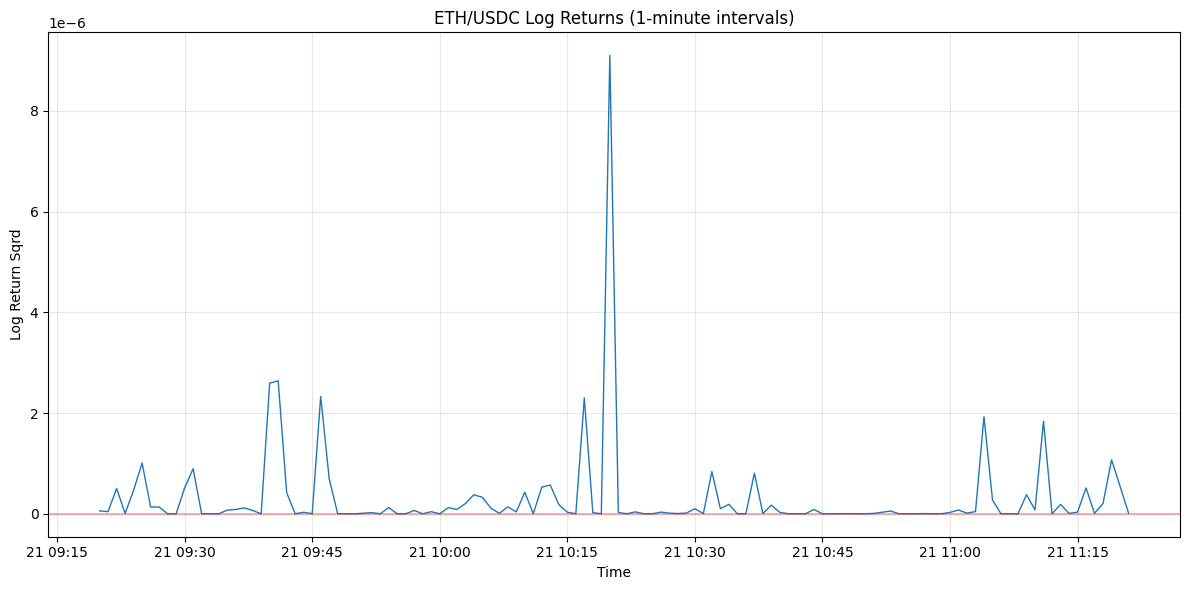

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(df_min_prices.index, df_min_prices['log_return_sqrd'], linewidth=1)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.title('ETH/USDC Log Returns (1-minute intervals)')
plt.ylabel('Log Return Sqrd')
plt.xlabel('Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

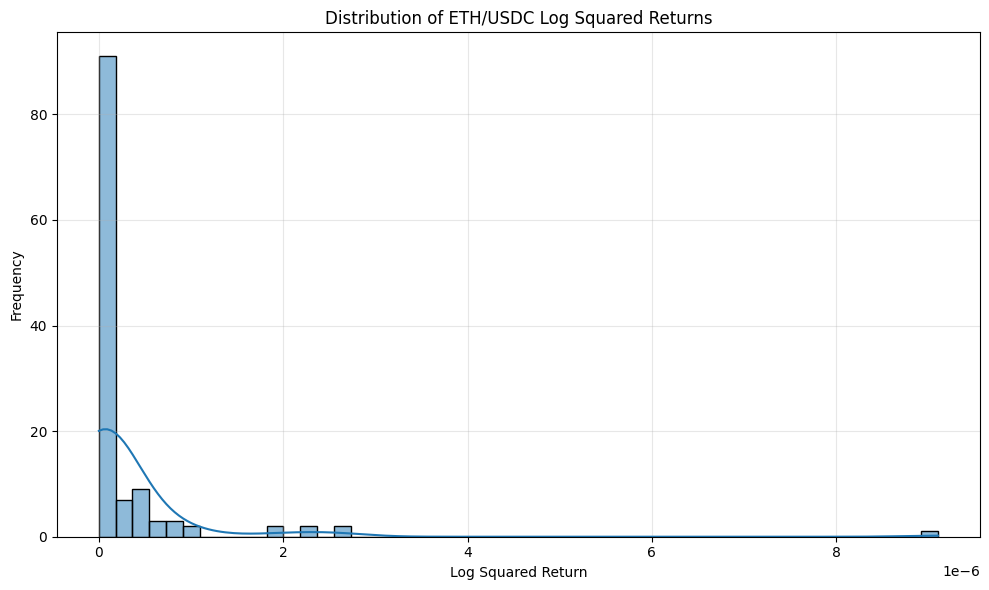

In [42]:
# Plot 2: Histogram of log returns with normal distribution overlay
plt.figure(figsize=(10, 6))
sns.histplot(df_min_prices['log_return_sqrd'].dropna(), bins=50, kde=True)
plt.title('Distribution of ETH/USDC Log Squared Returns')
plt.xlabel('Log Squared Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

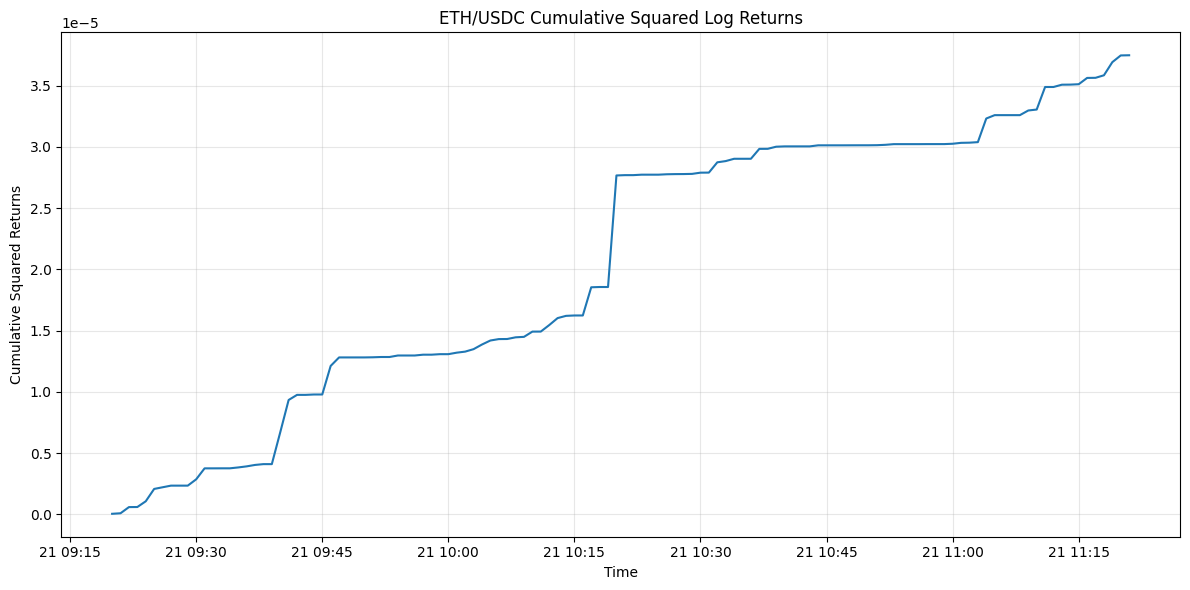

In [35]:
# Plot 4: Cumulative squared returns (shows volatility accumulation)
plt.figure(figsize=(12, 6))
plt.plot(.index, df_min_prices['log_return_sqrd'].cumsum(), linewidth=1.5)
plt.title('ETH/USDC Cumulative Squared Log Returns')
plt.ylabel('Cumulative Squared Returns')
plt.xlabel('Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot log returns

In [36]:
df_min_prices_row_log = df_min_prices.copy()

In [37]:
df_min_prices_row_log['raw_log_return'] = np.log(df_min_prices['eth_usdc_uniV3'] / df_min_prices['eth_usdc_shift_1'])

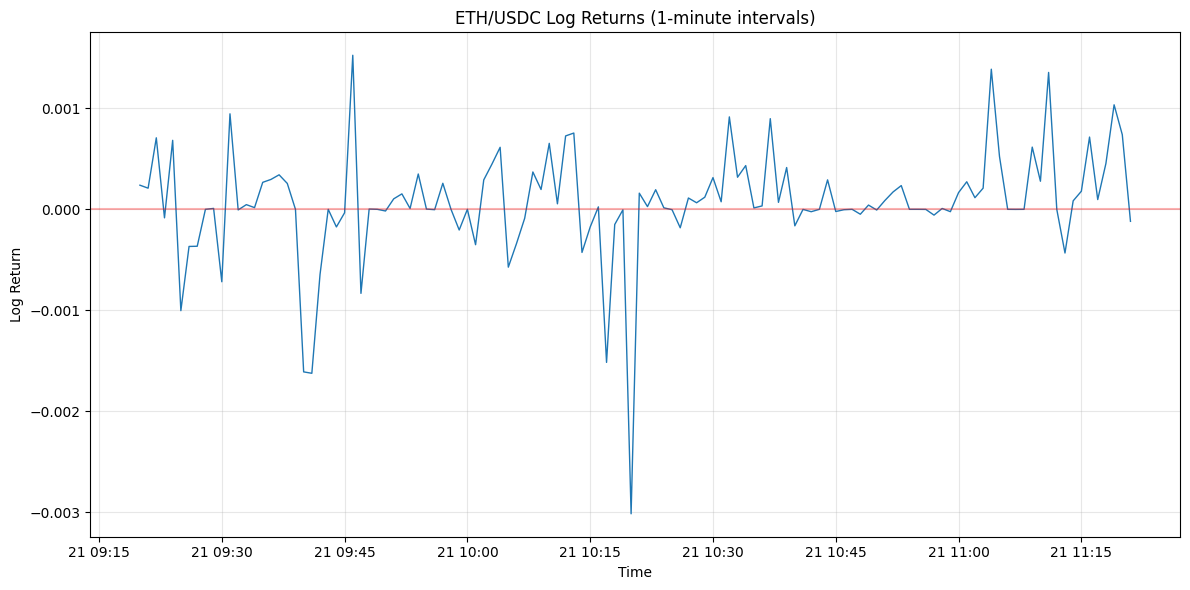

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(df_min_prices_row_log.index, df_min_prices_row_log['raw_log_return'], linewidth=1)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.title('ETH/USDC Log Returns (1-minute intervals)')
plt.ylabel('Log Return')
plt.xlabel('Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

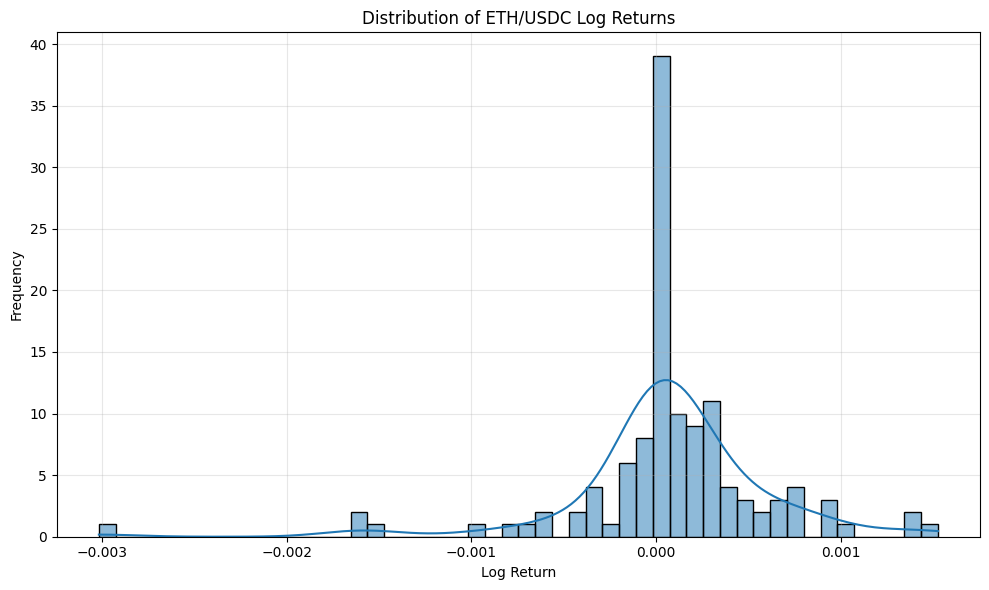

In [39]:
# Plot 2: Histogram of log returns with normal distribution overlay
plt.figure(figsize=(10, 6))
sns.histplot(df_min_prices_row_log['raw_log_return'].dropna(), bins=50, kde=True)
plt.title('Distribution of ETH/USDC Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

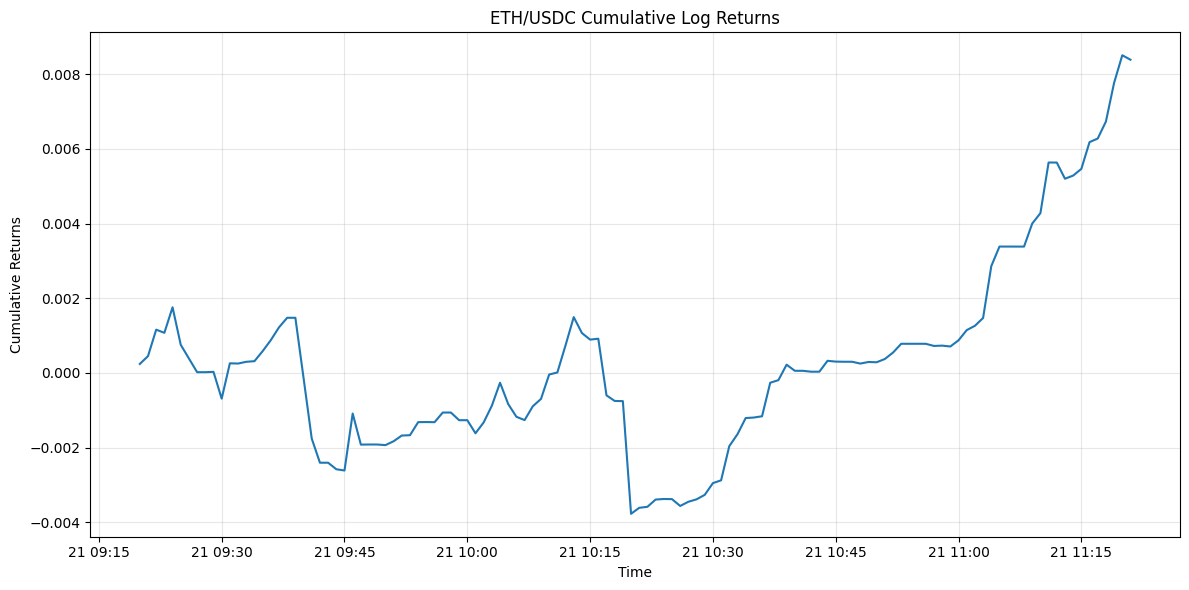

In [40]:
# Plot 4: Cumulative squared returns (shows volatility accumulation)
plt.figure(figsize=(12, 6))
plt.plot(df_min_prices_row_log.index, df_min_prices_row_log['raw_log_return'].cumsum(), linewidth=1.5)
plt.title('ETH/USDC Cumulative Log Returns')
plt.ylabel('Cumulative Returns')
plt.xlabel('Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
annual_factor = np.sqrt(365 * 24 * 60) # 525,600 minutes per year

In [47]:
df_min_prices.to_csv('uniV3_eth_usdc.csv')